# 보스턴 주택 가격 예측 프로젝트

## 1. 데이터 로딩 및 전처리

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 데이터 로딩
df = pd.read_csv("HousingData.csv")

# 결측치 확인 및 제거
df.dropna(inplace=True)

# 이상치 제거 (Z-score 방식)
from scipy.stats import zscore
df = df[(zscore(df.select_dtypes(include='number')) < 3).all(axis=1)]

# 특성/타겟 분리
X = df.drop(columns=["MEDV"])  # MEDV = 주택 가격
y = df["MEDV"]

# Min-Max 정규화
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 데이터 분할
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


## 2. 기본 모델: 다중 선형 회귀

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)
preds_lr = lr.predict(X_val)

print("Linear Regression")
print(f"MSE: {mean_squared_error(y_val, preds_lr):.4f}")
print(f"R² Score: {r2_score(y_val, preds_lr):.4f}")


Linear Regression
MSE: 7.4913
R² Score: 0.8418


## 3. 고급 모델: Random Forest, XGBoost, LightGBM

In [5]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    print(f"\n{name}")
    print(f"MSE: {mean_squared_error(y_val, preds):.4f}")
    print(f"R² Score: {r2_score(y_val, preds):.4f}")



Random Forest
MSE: 7.1274
R² Score: 0.8494

XGBoost
MSE: 7.9010
R² Score: 0.8331
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 671
[LightGBM] [Info] Number of data points in the train set: 269, number of used features: 12
[LightGBM] [Info] Start training from score 21.404461
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

C:\Users\shjun\AppData\Roaming\Python\Python310\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 지정된 파일을 찾을 수 없습니다
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\shjun\AppData\Roaming\Python\Python310\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Program Files\Python310\lib\subprocess.py", line 501, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Program Files\Python310\lib\subprocess.py", line 969, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Program Files\Python310\lib\subprocess.py", line 1438, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
C:\Users\shjun\AppData\Roa

## 4. 딥러닝 모델 (MLP)

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# GPU 충돌 방지
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_val, y_val), verbose=0)

mse_nn, mae_nn = model.evaluate(X_val, y_val, verbose=0)
print(f"MLP - MSE: {mse_nn:.4f}, MAE: {mae_nn:.4f}")


MLP - MSE: 8.6513, MAE: 2.2552


## 5. 딥러닝 학습 시각화

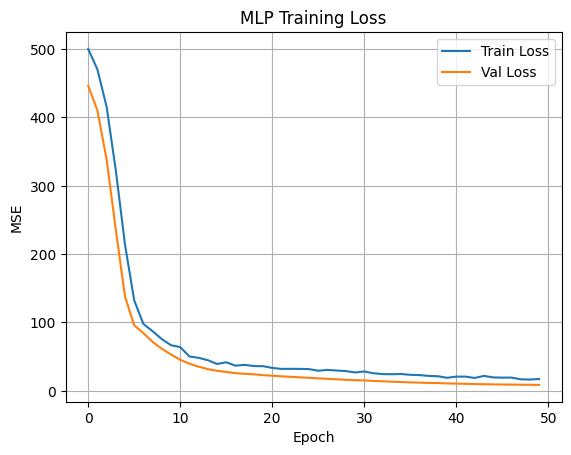

In [7]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('MLP Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()
